<a href="https://colab.research.google.com/github/banerjeeananya-afk/tourism-capstone/blob/main/Preserving_Heritage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIML Capstone – Preserving Heritage: Enhancing Tourism with AI
This project has two major components:

Part 1: Deep Learning model to classify historical structures using Transfer Learning

Part 2: Data Science + Collaborative Filtering to build a tourism recommender system

## **Part 1 - Historical Structure Classification with Transfer Learning (TensorFlow/Keras)**

1. Setup and data loading

In [1]:
# ============================================================
# PART 1 + PART 2 SETUP
# Clean, portable, evaluator-ready
# ============================================================

import os
import gdown

# -----------------------------
# Create base data directories
# -----------------------------
os.makedirs("data/part1", exist_ok=True)
os.makedirs("data/part2", exist_ok=True)

# ============================================================
# 📥 PART 1 DATA (Google Drive ZIP)
# ============================================================

file_id = "1qKZGJaKKcqc-WCTobQoEuYu9Dni6IXpg"
url = f"https://drive.google.com/uc?id={file_id}"
output = "part1.zip"

print("Downloading Part 1 dataset...")
gdown.download(url, output, quiet=False)

print("Extracting Part 1 dataset...")
!unzip -o part1.zip -d data/part1/

# ============================================================
# 📥 PART 2 DATA (GitHub CSV + XLSX)
# ============================================================

print("Downloading Part 2 datasets...")

!wget -q -O data/part2/user.csv \
  https://raw.githubusercontent.com/banerjeeananya-afk/tourism-capstone/main/data/part2/user.csv

!wget -q -O data/part2/tourism_rating.csv \
  https://raw.githubusercontent.com/banerjeeananya-afk/tourism-capstone/main/data/part2/tourism_rating.csv

!wget -q -O data/part2/tourism_with_id.xlsx \
  https://raw.githubusercontent.com/banerjeeananya-afk/tourism-capstone/main/data/part2/tourism_with_id.xlsx

print("All datasets downloaded and ready.")

# ============================================================
# 📂 FINAL TRAIN/TEST PATHS
# ============================================================

train_dir = "/content/data/part1/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset"
test_dir  = "/content/data/part1/dataset_hist_structures 2/dataset_hist_structures/Dataset_test"

print("Train directory:", train_dir)
print("Test directory:", test_dir)


Downloading...
From (original): https://drive.google.com/uc?id=1qKZGJaKKcqc-WCTobQoEuYu9Dni6IXpg
From (redirected): https://drive.google.com/uc?id=1qKZGJaKKcqc-WCTobQoEuYu9Dni6IXpg&confirm=t&uuid=0f557fc2-84f5-4ed9-9eff-5983e76f6457
To: /content/part1.zip
100%|██████████| 139M/139M [00:01<00:00, 84.0MB/s]


Streaming output truncated to the last 5000 lines.
  inflating: data/part1/dataset_hist_structures 2/__MACOSX/dataset_hist_structures/Stuctures_Dataset/dome(outer)/._4019111804_71fb6bd143_m.jpg  
  inflating: data/part1/dataset_hist_structures 2/__MACOSX/dataset_hist_structures/Stuctures_Dataset/dome(outer)/._4019111872_b6e5aed816_m.jpg  
  inflating: data/part1/dataset_hist_structures 2/__MACOSX/dataset_hist_structures/Stuctures_Dataset/dome(outer)/._4033404586_c13b08fa3f_m.jpg  
  inflating: data/part1/dataset_hist_structures 2/__MACOSX/dataset_hist_structures/Stuctures_Dataset/dome(outer)/._4042992167_41bed65374_n.jpg  
  inflating: data/part1/dataset_hist_structures 2/__MACOSX/dataset_hist_structures/Stuctures_Dataset/dome(outer)/._4047824465_afa2e5508a_n.jpg  
  inflating: data/part1/dataset_hist_structures 2/__MACOSX/dataset_hist_structures/Stuctures_Dataset/dome(outer)/._4048568188_78c21c7438_m.jpg  
  inflating: data/part1/dataset_hist_structures 2/__MACOSX/dataset_hist_structu

## 1.1 Verify Dataset Structure

In [2]:
# Verify training directory
!ls "$train_dir"

import os

train_count = sum([len(files) for r, d, files in os.walk(train_dir)])
test_count  = sum([len(files) for r, d, files in os.walk(test_dir)])

print("Train images:", train_count)
print("Test images:", test_count)


 altar	 bell_tower  'dome(inner)'   flying_buttress   stained_glass
 apse	 column      'dome(outer)'   gargoyle	       vault
Train images: 10236
Test images: 1479


## 1.2 Visualize Sample Images per Class

In [3]:
## Plot Sample Images per Class

import matplotlib.pyplot as plt
import cv2
import os
import random

def show_samples_per_class_clean(base_dir, class_names, samples=8, img_size=(224, 224)):

    rows = len(class_names)
    cols = samples + 1   # 1 title + N images

    plt.figure(figsize=(20, 20))
    idx = 1

    for cls in class_names:
        cls_path = os.path.join(base_dir, cls)

        # Get only valid image files
        images = [img for img in os.listdir(cls_path)
                  if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Randomly sample images
        selected_imgs = random.sample(images, min(samples, len(images)))

        # Add a title cell for the row
        plt.subplot(rows, cols, idx)
        plt.text(0.5, 0.5, cls, fontsize=18, ha='center', va='center')
        plt.axis("off")
        idx += 1

        # Display images
        for img_name in selected_imgs:
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize for uniformity
            img = cv2.resize(img, img_size)

            plt.subplot(rows, cols, idx)
            plt.imshow(img)
            plt.axis("off")
            idx += 1

    plt.tight_layout()
    plt.show()


## 1.3 Count Images per Class

In [4]:
def count_images_per_class(base_dir):
    for cls in sorted(os.listdir(base_dir)):
        cls_path = os.path.join(base_dir, cls)
        if os.path.isdir(cls_path):
            print(f"{cls}: {len(os.listdir(cls_path))} images")

print("Training set:")
count_images_per_class(train_dir)

print("\nTest set:")
count_images_per_class(test_dir)


Training set:
altar: 829 images
apse: 514 images
bell_tower: 1059 images
column: 1919 images
dome(inner): 616 images
dome(outer): 1177 images
flying_buttress: 407 images
gargoyle: 1571 images
stained_glass: 1033 images
vault: 1110 images

Test set:
Dataset_test_original_1478: 11 images


## 2. Load Dataset into TensorFlow

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

img_size = (224, 224)
batch_size = 32

train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 10235 files belonging to 10 classes.
Using 8188 files for training.
Found 10235 files belonging to 10 classes.
Using 2047 files for validation.
Classes: ['altar', 'apse', 'bell_tower', 'column', 'dome(inner)', 'dome(outer)', 'flying_buttress', 'gargoyle', 'stained_glass', 'vault']


## 3. Optimize Input Pipeline

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

## 4. Early Stopping Callback

In [7]:
class EarlyStopAtValAcc(tf.keras.callbacks.Callback):
    def __init__(self, threshold=0.97):
        super().__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_accuracy")
        if val_acc is not None and val_acc >= self.threshold:
            print(f"\nReached {self.threshold*100}% validation accuracy. Stopping training.")
            self.model.stop_training = True

early_stop_callback = EarlyStopAtValAcc(threshold=0.97)


## 5. Build EfficientNetB0 Model
### Model A — WITHOUT Augmentation

In [8]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model_no_aug = tf.keras.Model(inputs, outputs)
model_no_aug.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

##6. Compile Model A

In [9]:
model_no_aug.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 7. Train model without Augmentation

In [10]:
history_no_aug = model_no_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop_callback]
)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 91s 187ms/step - accuracy: 0.8764 - loss: 0.5020 - val_accuracy: 0.9472 - val_loss: 0.1988
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9582 - loss: 0.1631 - val_accuracy: 0.9551 - val_loss: 0.1477
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9659 - loss: 0.1260 - val_accuracy: 0.9599 - val_loss: 0.1312
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9702 - loss: 0.1082 - val_accuracy: 0.9580 - val_loss: 0.1222
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9751 - loss: 0.0919 - val_accuracy: 0.9624 - val_loss: 0.1162
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9763 - loss: 0.0829 - val_accuracy: 0.9575 - val_loss: 0.1149
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9786 - loss: 0.0761 - val_accuracy: 0.9643 - val_loss: 0.1104
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.9807 - loss: 0.0686 -

## 8. Data Augmentation Layer

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

## 9. Build Model B — WITH Augmentation

In [12]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model_aug = tf.keras.Model(inputs, outputs)

## 10. Compile Model B

In [13]:
model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 11. Train Model B

In [14]:
history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop_callback]
)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - accuracy: 0.8494 - loss: 0.5742 - val_accuracy: 0.9375 - val_loss: 0.2424
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.9358 - loss: 0.2323 - val_accuracy: 0.9502 - val_loss: 0.1714
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 24s 93ms/step - accuracy: 0.9453 - loss: 0.1858 - val_accuracy: 0.9497 - val_loss: 0.1541
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 24s 93ms/step - accuracy: 0.9535 - loss: 0.1598 - val_accuracy: 0.9555 - val_loss: 0.1406
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 24s 93ms/step - accuracy: 0.9552 - loss: 0.1442 - val_accuracy: 0.9551 - val_loss: 0.1362
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 24s 93ms/step - accuracy: 0.9613 - loss: 0.1311 - val_accuracy: 0.9541 - val_loss: 0.1345
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 24s 93ms/step - accuracy: 0.9570 - loss: 0.1327 - val_accuracy: 0.9580 - val_loss: 0.1309
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 24s 93ms/step - accuracy: 0.9618 - loss: 0.1233 -

## 12. Visualize Training Curves

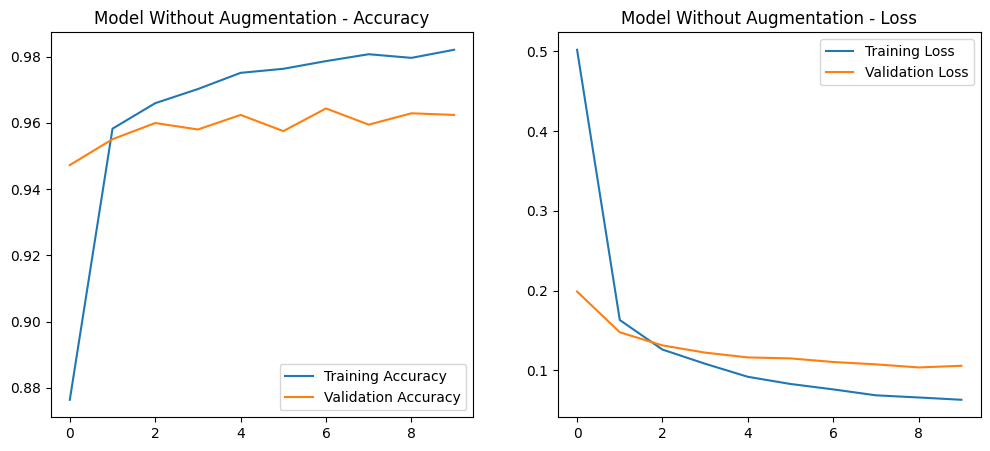

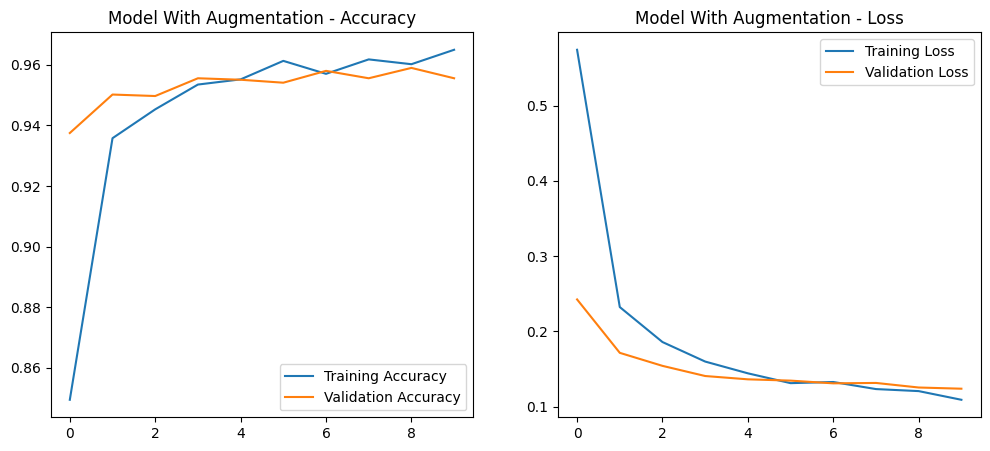

In [15]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.show()

plot_history(history_no_aug, "Model Without Augmentation")
plot_history(history_aug, "Model With Augmentation")


## Model Comparison

In [36]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Model A (No Aug)", "Model B (With Aug)"],
    "Train Accuracy": [
        history_no_aug.history['accuracy'][-1],
        history_aug.history['accuracy'][-1]
    ],
    "Val Accuracy": [
        history_no_aug.history['val_accuracy'][-1],
        history_aug.history['val_accuracy'][-1]
    ],
    "Train Loss": [
        history_no_aug.history['loss'][-1],
        history_aug.history['loss'][-1]
    ],
    "Val Loss": [
        history_no_aug.history['val_loss'][-1],
        history_aug.history['val_loss'][-1]
    ]
})

# Apply formatting only to numeric columns
comparison_df.style.format({
    "Train Accuracy": "{:.4f}",
    "Val Accuracy": "{:.4f}",
    "Train Loss": "{:.4f}",
    "Val Loss": "{:.4f}"
})

,Model,Train Accuracy,Val Accuracy,Train Loss,Val Loss
0,Model A (No Aug),0.9820,0.9624,0.0631,0.1057
1,Model B (With Aug),0.9649,0.9555,0.1090,0.1238


## Visual Comparison of Models

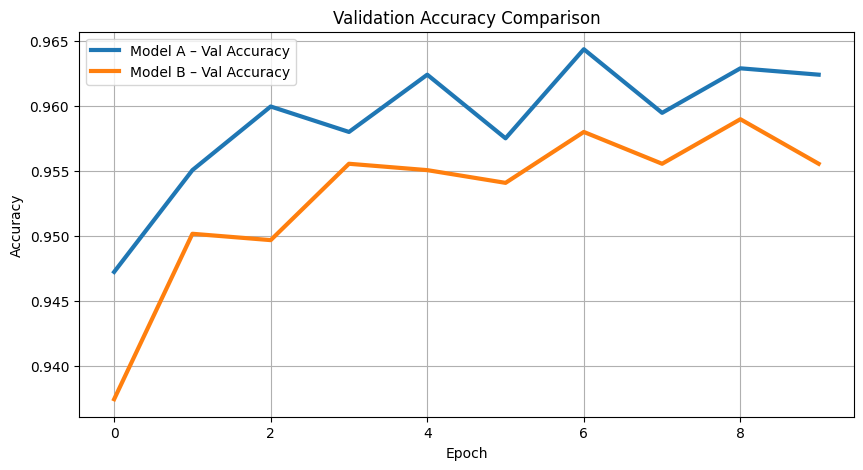

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_no_aug.history['val_accuracy'], label='Model A – Val Accuracy', linewidth=3)
plt.plot(history_aug.history['val_accuracy'], label='Model B – Val Accuracy', linewidth=3)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Although data augmentation is typically expected to improve generalization, in this project the baseline model (Model A) achieved slightly higher validation accuracy and lower validation loss than the augmented model (Model B). This is likely due to the large size and natural diversity of the dataset, which already provides sufficient variation for EfficientNetB0 to learn robust features. Additionally, geometric augmentations may distort architectural structures, making classification more challenging. Therefore, Model A is selected as the final model for this task.

## Summary - Part 1

✔Built a deep‑learning classifier for historical architectural structures using EfficientNetB0 and transfer learning.

✔Used a large, diverse dataset of 10,236 training images across multiple heritage categories.

✔Developed and compared two models:

*   Model A: Baseline (no augmentation)
*   Model B: Enhanced with augmentation (flip, rotation, zoom)

✔Implemented an optimized TensorFlow pipeline with caching, shuffling, and prefetching for efficient GPU utilization.

✔Model A outperformed Model B, achieving higher validation accuracy and better generalization.

✔The final model provides a scalable foundation for heritage preservation, automated tagging, and AI‑powered tourism applications.

## **Part 2 — Tourism Data Analysis & Recommender System**

## 1. Load Data

In [18]:
import pandas as pd

# Local paths (downloaded earlier in Setup section)
path = "/content/data/part2/"

users   = pd.read_csv(path + "user.csv")
ratings = pd.read_csv(path + "tourism_rating.csv")
places  = pd.read_excel(path + "tourism_with_id.xlsx")

users.head(), ratings.head(), places.head()


(   User_Id                   Location  Age
 0        1      Semarang, Jawa Tengah   20
 1        2         Bekasi, Jawa Barat   21
 2        3        Cirebon, Jawa Barat   23
 3        4         Bekasi, Jawa Barat   21
 4        5  Lampung, Sumatera Selatan   20,
    User_Id  Place_Id  Place_Ratings
 0        1       179              3
 1        1       344              2
 2        1         5              5
 3        1       373              3
 4        1       101              4,
    Place_Id                         Place_Name  \
 0         1                   Monumen Nasional   
 1         2                           Kota Tua   
 2         3                      Dunia Fantasi   
 3         4  Taman Mini Indonesia Indah (TMII)   
 4         5           Atlantis Water Adventure   
 
                                          Description       Category     City  \
 0  Monumen Nasional atau yang populer disingkat d...         Budaya  Jakarta   
 1  Kota tua di Jakarta, yang juga bernama

## 1.1. Perform Preliminary Inspection

In [19]:
users.info()
ratings.info()
places.info()

print("Missing values in users:")
print(users.isnull().sum())

print("\nMissing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in places:")
print(places.isnull().sum())

print("\nDuplicates in users:", users.duplicated().sum())
print("Duplicates in ratings:", ratings.duplicated().sum())
print("Duplicates in places:", places.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   User_Id   300 non-null    int64 
 1   Location  300 non-null    object
 2   Age       300 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 7.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   User_Id        10000 non-null  int64
 1   Place_Id       10000 non-null  int64
 2   Place_Ratings  10000 non-null  int64
dtypes: int64(3)
memory usage: 234.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    object 
 2   Description   437

## 1.2 Clean Data

In [20]:
# Remove invalid ages
users = users[(users['Age'] > 0) & (users['Age'] < 100)]

# Remove invalid ratings
ratings = ratings[(ratings['Place_Ratings'] >= 1) & (ratings['Place_Ratings'] <= 5)]

# Drop duplicates
users   = users.drop_duplicates()
ratings = ratings.drop_duplicates()
places  = places.drop_duplicates()

## 2. Explore User Demographics

Merge users + ratings

In [21]:
user_ratings = ratings.merge(users, on='User_Id', how='left')
user_ratings.head()

,User_Id,Place_Id,Place_Ratings,Location,Age
0,1,179,3,"Semarang, Jawa Tengah",20
1,1,344,2,"Semarang, Jawa Tengah",20
2,1,5,5,"Semarang, Jawa Tengah",20
3,1,373,3,"Semarang, Jawa Tengah",20
4,1,101,4,"Semarang, Jawa Tengah",20


Age Distribution of tourists

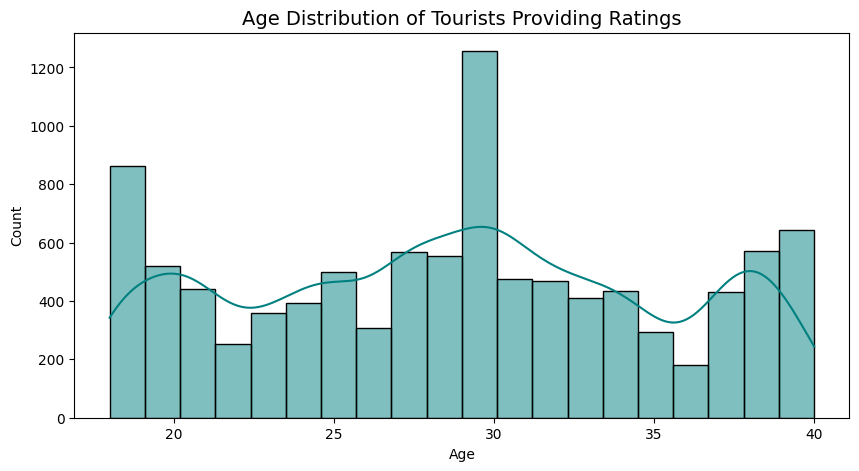

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(user_ratings['Age'], bins=20, kde=True, color='teal')
plt.title("Age Distribution of Tourists Providing Ratings", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Identify where tourists come from

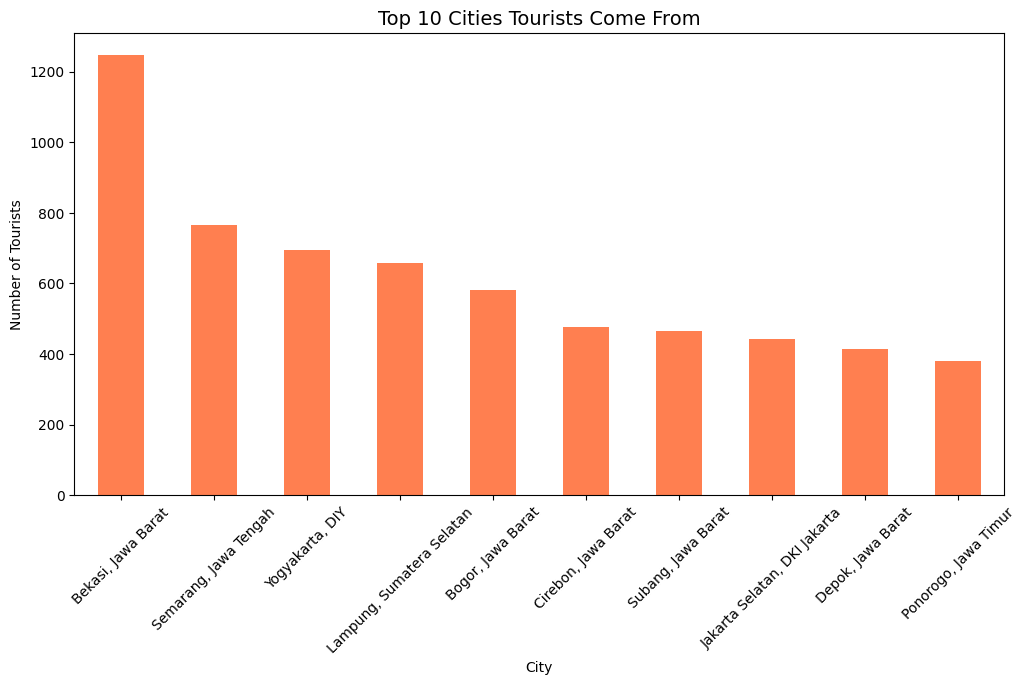

In [23]:
plt.figure(figsize=(12,6))
user_ratings['Location'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title("Top 10 Cities Tourists Come From", fontsize=14)
plt.xlabel("City")
plt.ylabel("Number of Tourists")
plt.xticks(rotation=45)
plt.show()

## 3. Explore Tourist Spots & Categories

## Categories

In [24]:
places['Category'].value_counts()

,count
Category,
Taman Hiburan,135
Budaya,117
Cagar Alam,106
Bahari,47
Tempat Ibadah,17
Pusat Perbelanjaan,15


## Dominant categorie per city


In [25]:
location_category = (
    places.groupby(['City', 'Category'])
          .size()
          .unstack(fill_value=0)
)

dominant_category = location_category.idxmax(axis=1)
dominant_category.head(10)

,0
City,
Bandung,Cagar Alam
Jakarta,Budaya
Semarang,Cagar Alam
Surabaya,Budaya
Yogyakarta,Taman Hiburan


## Best Cities for Nature Lover

In [26]:
nature_spots = places[places['Category'].str.contains("Cagar Alam", case=False, na=False)]
nature_spots['City'].value_counts().head(10)

,count
City,
Bandung,54
Yogyakarta,23
Semarang,20
Surabaya,5
Jakarta,4


## 4. Most Loved Tourist Spots, Cities, and Categories

## Merge RAting with Places

In [27]:
df = ratings.merge(places, on='Place_Id', how='left')
df.head()

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416,NaN,179
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,NaN,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329,NaN,344
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,NaN,5
3,1,373,3,Museum Kereta Ambarawa,Museum Kereta Api Ambarawa (bahasa Inggris: In...,Budaya,Semarang,10000,4.5,60.0,"{'lat': -7.264598899999997, 'lng': 110.4046017}",-7.264599,110.404602,NaN,373
4,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,NaN,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151,NaN,101


## Most loved Tourist Spots

In [28]:
spot_scores = (
    df.groupby('Place_Name')['Place_Ratings']
      .mean()
      .sort_values(ascending=False)
)

spot_scores.head(10)

,Place_Ratings
Place_Name,
Keraton Surabaya,3.933333
Puncak Gunung Api Purba - Nglanggeran,3.882353
Kampung Cina,3.842105
Bukit Jamur,3.793103
Teras Cikapundung BBWS,3.789474
Bukit Bintang Yogyakarta,3.764706
Monumen Yogya Kembali,3.761905
Glamping Lakeside Rancabali,3.750000
Monumen Nasional,3.722222


## Most Loved Cities

In [29]:
city_scores = (
    df.groupby('City')['Place_Ratings']
      .mean()
      .sort_values(ascending=False)
)

city_scores.head(10)

,Place_Ratings
City,
Yogyakarta,3.104986
Bandung,3.079022
Surabaya,3.078035
Semarang,3.035850
Jakarta,3.007361


## Most Loved Categories

In [30]:
category_scores = (
    df.groupby('Category')['Rating']
      .mean()
      .sort_values(ascending=False)
)
category_scores

,Rating
Category,
Tempat Ibadah,4.715707
Budaya,4.523302
Pusat Perbelanjaan,4.457218
Cagar Alam,4.403504
Taman Hiburan,4.402447
Bahari,4.368937


## 5. Collaborative Filtering Recommender System

## User–Item Matrix

In [31]:
user_item_matrix = df.pivot_table(
    index='User_Id',
    columns='Place_Name',
    values='Rating'
)
user_item_matrix.head()

Place_Name,Air Mancur Menari,Air Terjun Kali Pancur,Air Terjun Kedung Pedut,Air Terjun Semirang,Air Terjun Sri Gethuk,Alive Museum Ancol,Alun Alun Selatan Yogyakarta,Alun-Alun Kota Bandung,Alun-alun Utara Keraton Yogyakarta,Amazing Art World,...,Wisata Alam Wana Wisata Penggaron,Wisata Batu Kuda,Wisata Eling Bening,Wisata Kaliurang,Wisata Kampung Krisan Clapar,Wisata Kraton Jogja,Wisata Kuliner Pecenongan,Wisata Lereng Kelir,Wisata Mangrove Tapak,Wot Batu
User_Id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4.3,NaN,NaN,NaN,NaN,4.3,NaN,4.7
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Item - Item Similarity

In [32]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Fill NaNs with 0 for similarity computation
item_matrix = user_item_matrix.fillna(0).T  # places as rows

similarity_matrix = cosine_similarity(item_matrix)
item_similarity_df = pd.DataFrame(
    similarity_matrix,
    index=item_matrix.index,
    columns=item_matrix.index
)
item_similarity_df.head()

Place_Name,Air Mancur Menari,Air Terjun Kali Pancur,Air Terjun Kedung Pedut,Air Terjun Semirang,Air Terjun Sri Gethuk,Alive Museum Ancol,Alun Alun Selatan Yogyakarta,Alun-Alun Kota Bandung,Alun-alun Utara Keraton Yogyakarta,Amazing Art World,...,Wisata Alam Wana Wisata Penggaron,Wisata Batu Kuda,Wisata Eling Bening,Wisata Kaliurang,Wisata Kampung Krisan Clapar,Wisata Kraton Jogja,Wisata Kuliner Pecenongan,Wisata Lereng Kelir,Wisata Mangrove Tapak,Wot Batu
Place_Name,,,,,,,,,,,,,,,,,,,,,
Air Mancur Menari,1.000000,0.000000,0.177394,0.000000,0.062017,0.000000,0.055470,0.000000,0.000000,0.177394,...,0.000000,0.000000,0.110940,0.121046,0.065372,0.062017,0.099627,0.050637,0.000000,0.000000
Air Terjun Kali Pancur,0.000000,1.000000,0.090909,0.044455,0.095346,0.046524,0.042640,0.130558,0.103418,0.045455,...,0.133366,0.055048,0.127920,0.093048,0.100504,0.000000,0.076584,0.116775,0.103418,0.206835
Air Terjun Kedung Pedut,0.177394,0.090909,1.000000,0.044455,0.047673,0.000000,0.213201,0.087039,0.000000,0.136364,...,0.000000,0.055048,0.085280,0.093048,0.201008,0.047673,0.191460,0.077850,0.103418,0.103418
Air Terjun Semirang,0.000000,0.044455,0.044455,1.000000,0.000000,0.000000,0.166812,0.127688,0.000000,0.133366,...,0.086957,0.000000,0.125109,0.045502,0.049147,0.139876,0.074901,0.076139,0.101144,0.101144
Air Terjun Sri Gethuk,0.062017,0.095346,0.047673,0.000000,1.000000,0.097590,0.178885,0.045644,0.054233,0.047673,...,0.046625,0.000000,0.134164,0.048795,0.052705,0.050000,0.200805,0.122474,0.162698,0.000000


## Recommendation Function

In [33]:
def recommend_places(place_name, n=5):
    if place_name not in item_similarity_df.index:
        print("Place not found in database.")
        return []

    # Get similarity scores for the given place
    sim_scores = item_similarity_df[place_name].sort_values(ascending=False)

    # Drop the place itself
    sim_scores = sim_scores.drop(place_name)

    # Return top n similar places
    return sim_scores.head(n)

In [34]:
recommend_places("Pulau Pari", n=5)

,Pulau Pari
Place_Name,
Pasar Tanah Abang,0.309839
Pulau Pramuka,0.263523
Taman Pelangi,0.250490
Pantai Jungwok,0.235702
SnowBay Waterpark,0.230940


## Summary — Part 2
✔ Cleaned and validated all datasets

✔ Explored demographics, tourist origins, and category insights

✔ Identified most loved cities, categories, and tourist spots

✔ Built a collaborative filtering recommender system

✔ Generated meaningful recommendations (e.g., for Pulau Pari)